# BBM 409 - Programming Assignment 2

**PART 1:** Binary Classification with SVM (30 points)  
**PART 2:** Multiclass Classification (70 points)


* You can add as many cells as you want in-between each question.
* Please add comments to your code to explain your work.  
* Please add Markdown cells to answer the (non-coding) questions in the homework text. You can, however, refer to the outputs of code cells without adding them as images to the Markdown cell unless you are requested to do otherwise.
* Please be careful about the order of runs of cells. Doing the homework, it is likely that you will be running the cells in different orders, however, they will be evaluated in the order they appear. Hence, please try running the cells in this order before submission to make sure they work.    
* Please refer to the homework text for any implementation detail. Though you are somewhat expected to abide by the comments in the below cells, they are mainly just provided for guidance. That is, as long as you are not completely off this structure and your work pattern is understandable and traceable, it is fine. For instance, you do not have to implement a particular function within a cell just because the comment directs you to do so.
* This document is also your report. Show your work.

###  Mustafa Emir Tezcan - 2230356092

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

---
# PART 1: BINARY CLASSIFICATION WITH SVM (30 POINTS)
---

## Load the Sonar Dataset from UCI Repository

In [2]:
print("Loading Sonar dataset...")
sonar = fetch_ucirepo(id=151)
X_sonar = sonar.data.features
y_sonar = sonar.data.targets

Loading Sonar dataset...


## Encode the Target Labels using LabelEncoder()

In [3]:
label_encoder = LabelEncoder()
y_sonar_encoded = label_encoder.fit_transform(y_sonar) # R=1, M=0

## Split the Data into 80% Training and 20% Testing Sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_sonar, y_sonar_encoded, test_size=0.2, random_state=42, stratify=y_sonar_encoded)

---
## 1.1. Linear Kernel SVM without Hyperparameter Tuning (5 points)
---

## Create a Pipeline with StandardScaler and Linear SVM

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

## Train the Linear SVM Model

In [6]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'


## Predict on the Test Set and Calculate Accuracies and Print it

In [7]:
y_pred_linearSVM = pipeline.predict(X_test)

In [8]:
accuracy_linearSVM = accuracy_score(y_test, y_pred_linearSVM)

In [9]:
print(f"Accuracy: {accuracy_linearSVM:.4f}")

Accuracy: 0.7619


## Display Classification Report for Linear SVM

In [10]:
print("Classification Report for Linear SVM:")
print (classification_report(y_test, y_pred_linearSVM, target_names=label_encoder.classes_))

Classification Report for Linear SVM:
              precision    recall  f1-score   support

           M       0.73      0.86      0.79        22
           R       0.81      0.65      0.72        20

    accuracy                           0.76        42
   macro avg       0.77      0.76      0.76        42
weighted avg       0.77      0.76      0.76        42



## Display Confusion Matrix for Linear SVM

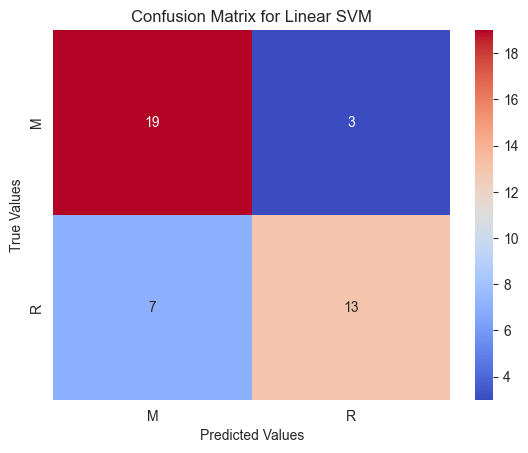

In [11]:
cf_matrix = confusion_matrix(y_test, y_pred_linearSVM)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.title('Confusion Matrix for Linear SVM')
plt.show()

---
## 1.2. SVM with GridSearchCV and 5-Fold Cross-Validation (15 points)
---

## Create a Pipeline for GridSearchCV

In [12]:
pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

## Define the Parameter Grid for Different Kernels

In [13]:
param_grid = [
    {
        'svm__kernel': ['linear'], # linear kernel
        'svm__C': [0.1, 1, 10, 100]
    },
    {
        'svm__kernel': ['rbf'], # rbf kernel
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01]
    },
    {
        'svm__kernel': ['poly'], # polynomial kernel
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01],
        'svm__degree': [2, 3, 4]
    }
]

## Create Stratified 5-Fold Cross-Validation

In [14]:
stratified_5_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Initialize and Run GridSearchCV on Training Data

In [15]:
grid_search = GridSearchCV(estimator=pipeline_gs, param_grid=param_grid, cv=stratified_5_fold, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"[{'svm__C': [0.1, 1, ...], 'svm__kernel': ['linear']}, {'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto', ...], 'svm__kernel': ['rbf']}, ...]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


## Display Best Parameters and Cross-Validation Score

In [16]:
print("Best Parameters from GridSearchCV:")
print(grid_search.best_params_)
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Best Parameters from GridSearchCV:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best Cross-Validation Score: 0.8615


## Evaluate the Best Model on the Test Set

In [17]:
best_model = grid_search.best_estimator_
y_pred_tunedSVM = best_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tunedSVM)
print(f"Accuracy : {accuracy_tuned:.4f}")

Accuracy : 0.8810


## Display Top 5 Parameter Combinations

In [18]:
results_df = pd.DataFrame(grid_search.cv_results_)
top_5_parameters = results_df.nlargest(5, 'mean_test_score')
print("Top 5 Parameter Combinations:")
display(top_5_parameters[['params', 'mean_test_score', 'std_test_score','split0_test_score','split1_test_score','split2_test_score','split3_test_score','split4_test_score']])

Top 5 Parameter Combinations:


,params,mean_test_score,std_test_score,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.861497,0.030604,0.852941,0.909091,0.818182,0.878788,0.848485
13,"{'svm__C': 10, 'svm__gamma': 'auto', 'svm__ker...",0.861497,0.030604,0.852941,0.909091,0.818182,0.878788,0.848485
16,"{'svm__C': 100, 'svm__gamma': 'scale', 'svm__k...",0.861497,0.030604,0.852941,0.909091,0.818182,0.878788,0.848485
17,"{'svm__C': 100, 'svm__gamma': 'auto', 'svm__ke...",0.861497,0.030604,0.852941,0.909091,0.818182,0.878788,0.848485
48,"{'svm__C': 10, 'svm__degree': 3, 'svm__gamma':...",0.850089,0.066305,0.735294,0.939394,0.848485,0.878788,0.848485


## Display Classification Report for Tuned SVM

In [19]:
print("Classification Report for Tuned SVM:")
print(classification_report(y_test, y_pred_tunedSVM, target_names=label_encoder.classes_))

Classification Report for Tuned SVM:
              precision    recall  f1-score   support

           M       0.84      0.95      0.89        22
           R       0.94      0.80      0.86        20

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42



## Display Confusion Matrix for Tuned SVM

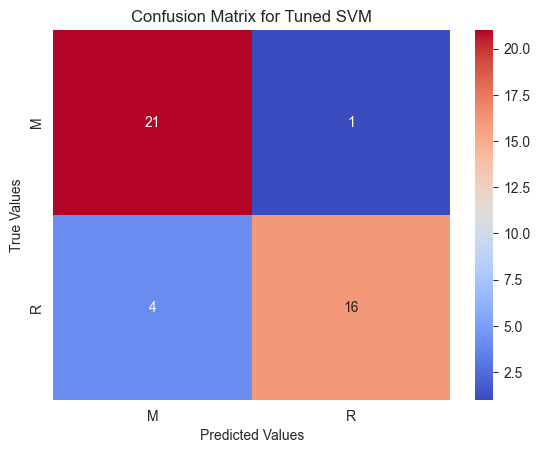

In [20]:
cf_matrix_tuned = confusion_matrix(y_test, y_pred_tunedSVM)
sns.heatmap(cf_matrix_tuned, annot=True, fmt='d', cmap='coolwarm', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.title('Confusion Matrix for Tuned SVM')
plt.show()

## Compare Linear SVM vs Tuned SVM Results. Compare experimental results. Explain the performance impact of linear and nonlinear kernels. Why is kernel trick important? Also explain why using k-fold cross validation is more advantageous than train-test split. (10 points)

In this nearly balanced test subset consisting of 22 Mine and 20 Rock instances, accuracy serves as a primary metric for evaluation; however, the F1 score remains a critical measure to account for the precision-recall trade-off, which is vital even in balanced scenarios to ensure model robustness. An analysis of the confusion matrices reveals that the Linear Kernel SVM achieved an accuracy of 76% on the 42-sample test set, correctly classifying 32 instances (composed of 19 True Negatives and 13 True Positives). While this model demonstrated a strong recall of 86% for the Mine class, it showed significant weakness regarding the Rock class, yielding a recall of only 65%. Consequently, approximately 35% of the Rock instances were misclassified as Mines, indicating a high false positive rate for the Mine class.

In contrast, Tuned SVM showed a significant improvement in predictive ability, correctly identifying 37 out of 42 test instances, achieving 88% accuracy. As evidenced by the classification report, the Tuned SVM outperformed the Linear SVM across almost all metrics. Most notably, the recall for the Rock class previously the linear model's weakest point saw a significant increase from 65% to 80%. Concurrent improvements in precision further validated that the model was not only capturing more positive instances but doing so with greater reliability. This overall uplift in both precision and recall contributed to a higher F1 score, confirming that the tuned model offers superior generalization.

The performance gap between the two models can be attributed to the mechanics of the Support Vector Machine. The Linear SVM attempts to separate classes using a flat hyperplane, which is often insufficient for complex data structures. The Tuned SVM utilizes the "kernel trick," a method that allows the algorithm to operate in a high-dimensional feature space without explicitly calculating the transformation. This enables the model to behave as if the data were projected into higher dimensions where classes that are non-linearly separable in the original space (a cluster surrounded by a ring of another class) become separable while maintaining low computational costs. By employing non-linear kernels such as the Radial Basis Function (RBF), the Tuned SVM establishes more flexible and successful decision boundaries compared to the rigid separation of the linear approach.

While model performance in a simple train-test split can fluctuate significantly depending on factors like the random state, K-Fold Cross-Validation offers a much more robust approach. After initially setting aside the test set, this method divides the remaining training data into K distinct parts (folds). Each of these K folds serves as the validation data in turn, while the remaining folds are used for training. When combined with Grid Search, this cycle is repeated for every hyperparameter variation, and the results are averaged across the K iterations to identify the best-performing model.  Finally, similar to the standard split approach, the optimal model is retrained on the entire training set (the full 80%) and evaluated on the 20% unseen data. This methodology ensures maximum utility from limited data, reduces variance and inconsistency, and helps detect overfitting. Although this process is computationally slower, it provides high reliability and is particularly critical when working with smaller datasets.

---
# PART 2: MULTICLASS CLASSIFICATION (70 POINTS)
---

## Load the Dry Beans Dataset from UCI Repository

In [21]:
print("Loading Dry Beans dataset...")
dry_bean = fetch_ucirepo(id=602)
X_beans = dry_bean.data.features
y_beans = dry_bean.data.targets

Loading Dry Beans dataset...


## Encode the Target Labels using LabelEncoder

In [22]:
label_encoder_beans = LabelEncoder()
y_beans_encoded = label_encoder_beans.fit_transform(y_beans)

## Split the Data into 80% Training and 20% Testing Sets

In [23]:
X_train_beans, X_test_beans, y_train_beans, y_test_beans = train_test_split(X_beans, y_beans_encoded, test_size=0.2, random_state=42, stratify=y_beans_encoded)

## Scale the Features using StandardScaler

In [24]:
standard_scaler = StandardScaler()
X_train_beans_scaled = standard_scaler.fit_transform(X_train_beans)
X_test_beans_scaled = standard_scaler.transform(X_test_beans)

---
## 2.1. Multinomial Logistic Regression (20 points)
---

## Define the Multinomial Logistic Regression Class

In [25]:
class MultinomialLogisticRegression:
    def __init__(self, learning_rate, epochs, reg_lambda):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.reg_lambda = reg_lambda
        self.weights = None
        self.bias = None

    def _softmax(self, X):
        z = np.dot(X, self.weights) + self.bias
        z-= np.max(z, axis=1, keepdims=True)  # For numerical stability
        exp_z = np.exp(z)
        probabilities = exp_z / np.sum(exp_z, axis=1, keepdims=True)
        return probabilities

    def _cross_entropy(self, y_true, y_pred):
        epsilon = 1e-15 # to avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        cross_entropy= -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]

        l2_reg= (self.reg_lambda / 2) * np.sum(self.weights ** 2) # L2 regularization

        loss= cross_entropy + l2_reg
        return loss

    def fit(self, X, y):
        N, D = X.shape # number of samples, number of features

        K= len(np.unique(y)) # number of classes

        self.weights= np.zeros((D, K))
        self.bias= np.zeros(K)

        y_one_hot= np.eye(K)[y]

        for epoch in range(self.epochs):
            y_pred= self._softmax(X)
            gradient_bias = -np.sum(y_one_hot - y_pred, axis=0) / N
            gradient_weights = -np.dot(X.T, (y_one_hot - y_pred)) / N

            gradient_weights += self.reg_lambda * self.weights # L2 regularization

            self.weights -= self.learning_rate * gradient_weights
            self.bias -= self.learning_rate * gradient_bias
        return self # for pipeline compatibility
    def predict_proba(self, X):
        return self._softmax(X)
    def predict(self, X):
        y_pred = self._softmax(X)
        return np.argmax(y_pred, axis=1)
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    def get_params(self, deep=True):
        return {
            'learning_rate': self.learning_rate,
            'epochs': self.epochs,
            'reg_lambda': self.reg_lambda
        }
    def set_params(self, **params):
        for key, value in params.items():
            if hasattr(self, key):
                setattr(self, key, value)
        return self

## Define Hyperparameter Grid for Multinomial Logistic Regression

In [26]:
hyp_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'epochs': [200,300,500],
    'reg_lambda': [0.0, 0.01, 0.1]
}

## Run GridSearchCV for Multinomial Logistic Regression

In [27]:
multn_log_reg= MultinomialLogisticRegression(learning_rate=0.01, epochs=200, reg_lambda=0.0) #initialize with default starting values
grid_search_lg= GridSearchCV(estimator=multn_log_reg, param_grid=hyp_param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search_lg.fit(X_train_beans_scaled, y_train_beans)

,estimator,<__main__.Mul...001CCF17FE510>
,param_grid,"{'epochs': [200, 300, ...], 'learning_rate': [0.01, 0.05, ...], 'reg_lambda': [0.0, 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


## Evaluate Multinomial Logistic Regression on Test Set

In [28]:
best_multn_lg_model= grid_search_lg.best_estimator_
y_pred_multn_lg= best_multn_lg_model.predict(X_test_beans_scaled)
accuracy_multn= accuracy_score(y_test_beans, y_pred_multn_lg)
print(f"Accuracy : {accuracy_multn:.4f}")

Accuracy : 0.9104


## Display Classification Report for Multinomial Logistic Regression

In [29]:
print("Classification Report for Multinomial Logistic Regression:")
print(classification_report(y_test_beans, y_pred_multn_lg, target_names=label_encoder_beans.classes_))

Classification Report for Multinomial Logistic Regression:
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.86      0.91       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.91      0.95      0.93       326
    DERMASON       0.90      0.91      0.91       709
       HOROZ       0.94      0.95      0.94       386
       SEKER       0.92      0.94      0.93       406
        SIRA       0.85      0.84      0.84       527

    accuracy                           0.91      2723
   macro avg       0.93      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723



## Display Confusion Matrix for Multinomial Logistic Regression

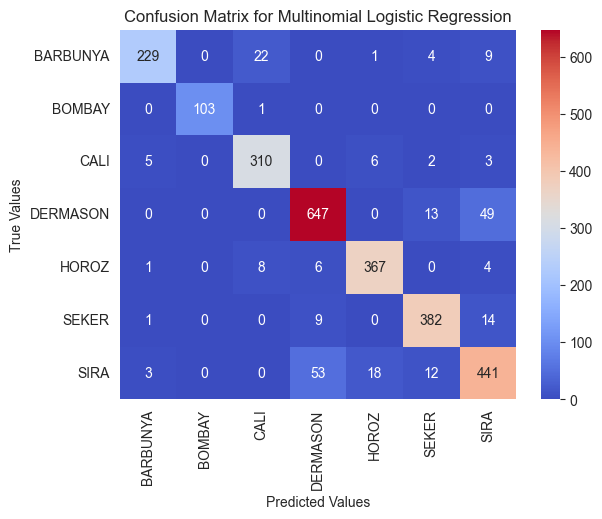

In [30]:
cf_matrix_multn = confusion_matrix(y_test_beans, y_pred_multn_lg)
sns.heatmap(cf_matrix_multn, annot=True, fmt='d', cmap='coolwarm', xticklabels=label_encoder_beans.classes_, yticklabels=label_encoder_beans.classes_)
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.title('Confusion Matrix for Multinomial Logistic Regression')
plt.show()

---
## 2.2. Decision Tree (20 points)
---

###  Define the Decision Tree model. Use GridSearchCV to find the best hyperparameters. Perform multiclass classification on the Dry Beans dataset. Print best hyperparameters, classification report and confusion matrix. (15 points)

## Define Hyperparameter Grid for Decision Tree

In [31]:
hyp_param_grid_tree = {
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

## Run GridSearchCV for Decision Tree

In [32]:
decision_tree = DecisionTreeClassifier(random_state=42)
grid_search_decision_tree = GridSearchCV(estimator=decision_tree, param_grid=hyp_param_grid_tree, cv=5, n_jobs=-1, scoring='accuracy')
grid_search_decision_tree.fit(X_train_beans_scaled, y_train_beans)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


## Display Classification Report for Decision Tree

In [33]:
best_tree_model = grid_search_decision_tree.best_estimator_
y_pred_tree = best_tree_model.predict(X_test_beans_scaled)
accuracy_tree = accuracy_score(y_test_beans, y_pred_tree)
print(f"Accuracy : {accuracy_tree:.4f}")

Accuracy : 0.9071


In [34]:
print("Classification Report for Decision Tree:")
print(classification_report(y_test_beans, y_pred_tree, target_names=label_encoder_beans.classes_))

Classification Report for Decision Tree:
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.92      0.92       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.96      0.92      0.94       386
       SEKER       0.92      0.94      0.93       406
        SIRA       0.84      0.83      0.84       527

    accuracy                           0.91      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723



## Display Confusion Matrix for Decision Tree

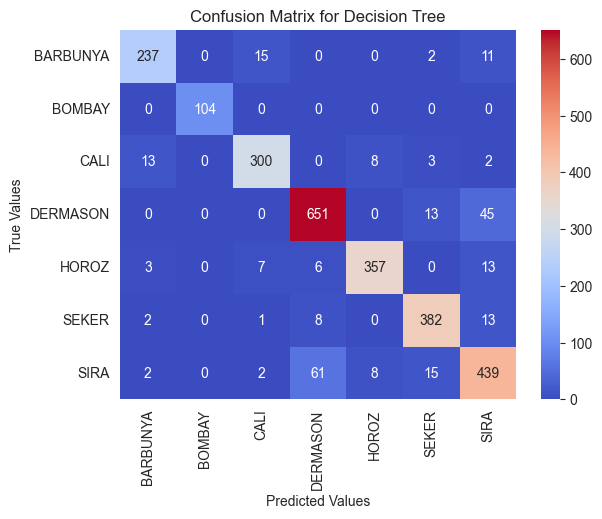

In [35]:
cf_matrix_tree = confusion_matrix(y_test_beans, y_pred_tree)
sns.heatmap(cf_matrix_tree, annot=True, fmt='d', cmap='coolwarm', xticklabels=label_encoder_beans.classes_, yticklabels=label_encoder_beans.classes_)
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

###  Describe how a decision tree builds its decision structure. (5 points)

Decision trees utilize a top-down, greedy approach, making the locally optimal choice at each step to construct the model.


**1.Starting To Build the Tree:**

The process begins at the root node, which encapsulates the entire dataset. At each node, the algorithm searches for the optimal query (split condition) to partition the data into two or more subsets (depending on the algorithm and implementation). To achieve this, the algorithm iterates through every feature in the dataset, aiming to maximize the homogeneity (purity) of the resulting groups.

**2.Choosing the Best Split:**

To evaluate the performance of a potential split, mathematical metrics are used to quantify "purity." The choice of metric depends on the task (Classification or Regression).

**2.1 Gini Impurity:**
Gini Impurity measures the probability that a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset. It favors larger partitions and is computationally faster than entropy because it avoids logarithmic calculations.
$$Gini(S) = 1 - \sum_{i=1}^{c} (p_i)^2$$

Where $p_i$ is the probability of an element belonging to a particular class $i$. A Gini score of 0 indicates pure data (all elements belong to the same class).

**2.2 Information Gain and Entropy:**
Entropy measures the amount of uncertainty or disorder in the data. Information Gain calculates the reduction in entropy achieved by splitting the dataset on a specific attribute. The algorithm chooses the feature that yields the highest Information Gain.
$$Entropy(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$
$$IG(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} Entropy(S_v)$$
Where $S$ is the current dataset, and $S_v$ is the subset of $S$ where attribute $A$ has value $v$. Lower entropy implies higher purity.

**2.3 Variance Reduction (for Regression Trees):**
For regression tasks (where the target is a continuous value), standard purity metrics do not apply. Instead, the algorithm aims to minimize the Variance within the nodes. The split that results in the greatest reduction in variance (or standard deviation) is chosen.

**3.Recursive Partitioning and Stopping Criteria:**

Once the best query is identified based on the metrics above, the data is partitioned. This process is repeated recursively for each resulting branch. The partitioning process continues until one of the following stopping criteria is met:
- Maximum Depth: The tree reaches a predefined maximum depth.
- Minimum Samples per Leaf: A node has fewer than a specified number of samples.
- Pure Nodes: All samples in a node belong to the same class .

The final nodes where the process terminates are designated as leaf nodes, representing the final output or prediction .

---
## 2.3. XGBoost (20 points)
---

###  Define the XGBoost model. Use GridSearchCV to find the best hyperparameters. Perform multiclass classification on the Dry Beans dataset. Print best hyperparameters, classification report and confusion matrix(10 points)

## Define Hyperparameter Grid for XGBoost

In [36]:
hyp_param_grid_xgboost = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

## Run GridSearchCV for XGBoost

In [37]:
xgb_model = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42)
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=hyp_param_grid_xgboost, cv=5, n_jobs=-1, scoring='accuracy') # n_jobs=-1 to use all available cores
grid_search_xgb.fit(X_train_beans_scaled, y_train_beans)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


## Evaluate XGBoost on Test Set

In [38]:
print("Best Parameters from GridSearchCV for XGBoost:")
print(grid_search_xgb.best_params_)
print(f"Best Cross-Validation Score: {grid_search_xgb.best_score_:.4f}")
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_beans_scaled)
accuracy_xgb = accuracy_score(y_test_beans, y_pred_xgb)
print(f"Accuracy : {accuracy_xgb:.4f}")

Best Parameters from GridSearchCV for XGBoost:
{'colsample_bytree': 1.0, 'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 100, 'subsample': 1.0}
Best Cross-Validation Score: 0.9312
Accuracy : 0.9203


## Display Classification Report for XGBoost

In [39]:
print("Classification Report for XGBoost:")
print(classification_report(y_test_beans, y_pred_xgb, target_names=label_encoder_beans.classes_))

Classification Report for XGBoost:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.93      0.94       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.95      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



## Display Confusion Matrix for XGBoost

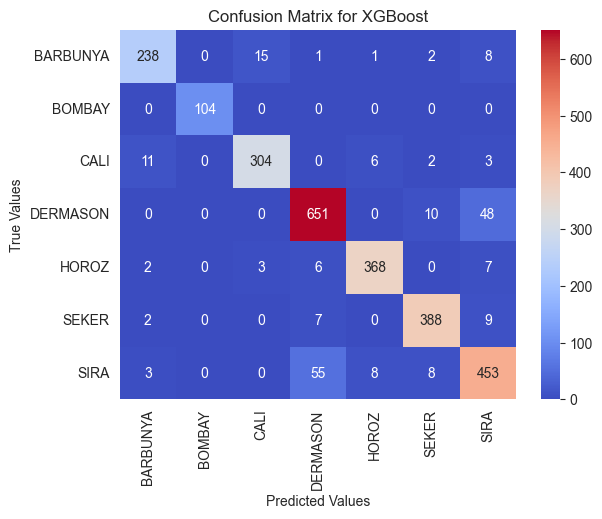

In [40]:
cf_matrix_xgb = confusion_matrix(y_test_beans, y_pred_xgb)
sns.heatmap(cf_matrix_xgb, annot=True, fmt='d', cmap='coolwarm', xticklabels=label_encoder_beans.classes_, yticklabels=label_encoder_beans.classes_)
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.title('Confusion Matrix for XGBoost')
plt.show()

### What are the revolutionary features of XGBoost compared to other tree-based models? (10 points)

Extreme Gradient Boosting (XGBoost) is a scalable and highly optimized implementation of gradient boosting machines (GBMs). It has improved the capabilities of traditional tree-based models such as Random Forests and classical Gradient Boosted Decision Trees (GBDT).

**Innovations of XGBoost:**
1. **Regularization:** Traditional GBDT models primarily focus on minimizing the loss function without explicitly controlling model complexity. XGBoost introduces L1 (Lasso) and L2 (Ridge) regularization terms to the objective function. This helps:
- Reduce overfitting
- Improve model generalization
- Produce more stable and robust trees
This built-in regularization is one of the core innovations that make XGBoost superior to classic GBDT.
2. **Second-Order Gradient Optimization:** XGBoost uses both first-order (gradient) and second-order (Hessian) derivatives in its optimization process. This helps:
- Achieve faster convergence
- More accurate tree splits
- Better handling of complex loss functions
3. **Weighted Quantile Sketch:** XGBoost implements a novel algorithm for approximate tree learning called Weighted Quantile Sketch.This helps:
- Efficiently handle large datasets
- High performance in distributed computing environments
- Support weighted data instances
4. **Parallel and Distributed Computing:** While boosting is inherently sequential, XGBoost parallelizes the node splitting and feature selection phases within each tree. This helps:
- Significantly speed up training times by utilizing multi-core processors for split finding.
- Handle massive datasets that do not fit into memory.
- Scalability across clusters
5. **Sparsity Awareness:** XGBoost has built-in support for handling sparse data . This helps:
- Efficiently manage datasets with missing values
- Reduce memory consumption
- Improve training speed
6. **Custom Objective Functions and Evaluation Metrics:** XGBoost allows users to define custom loss functions and evaluation metrics. This  helps:
- Tailor models to specific problems
- Optimize for domain-specific performance measures
- Enhance model interpretability
Overall, XGBoost's combination of regularization, advanced optimization techniques, scalability, and flexibility has made it a revolutionary tool in the field of machine learning, particularly for structured data.

###  Compare the classification results of your Multinomial Logistic Regression, Decision Tree, and XGBoost models on the Dry Beans dataset. Discuss the comparison in terms of overall model performance, risk of overfitting, model complexity and the scenarios in which each model is most effective. (10 points)

**1.Overall Model Performance**


As observed from the classification reports and confusion matrices, all three models demonstrated strong performance on the Dry Beans dataset. XGBoost achieved the highest accuracy at 92.03%, followed closely by the Multinomial Logistic Regression at 91.04%, and Decision Tree at 91.04%. The superior performance of XGBoost can be attributed to its ensemble learning approach, which combines multiple weak learners to create a robust model capable of capturing complex patterns in the data.

Given the imbalanced nature of the dataset ( DERMASON has 709 samples while BOMBAY has only 104), relying solely on accuracy can be misleading. However, in this specific case, the Weighted Average F1-Scores align perfectly with the accuracy metrics (0.92 for XGBoost, 0.91 for others), indicating that the models are not merely biasing towards the majority class but are learning the patterns effectively across the board.

All models achieved near-perfect scores (F1-score: 1.00) for the Bombay class. This confirms that Bombay beans possess distinct physical characteristics (likely size and shape) that create a high degree of linear separability from other types. Note: Multinomial Logistic Regression had a negligible drop in recall (0.99), missing just 1 sample out of 104.

The SIRA class, unlike the BOMBAY class, was found to be a difficult class to distinguish, with an f1 score of 0.86 even in XGBoost.

**2.Model Complexity and Risk of Overfitting**

Overfitting refers to a model's tendency to memorize training data, including noise and outliers, rather than learning the underlying patterns. This often results in excellent performance on training data but poor generalization to unseen test data. The risk of overfitting is closely tied to model complexity, which describes a model's capacity to capture complex relationships in the data.

- **Multinomial Logistic Regression:**

Multinomial Logistic Regression is a linear model that operates by constructing hyperplanes to separate classes. Due to this structural rigidity, it has low model complexity. It is fundamentally a "high bias, low variance" algorithm. The risk is minimal. Because the model is restricted to learning linear relationships, it lacks the flexibility to memorize noise or outliers in the training data.It generally generalizes well, provided the underlying data distribution is somewhat linear. However, its primary risk is underfitting, as it may fail to capture complex, non-linear patterns essential for high-precision classification.

- **Decision Trees:**

 In contrast to linear models, Decision Trees are non-linear algorithms that split data hierarchically based on feature values. Without constraints, a Decision Tree has potentially infinite complexity, as it can continue splitting until every leaf node contains a single sample.The risk is extremely high. Decision Trees are prone to memorizing the training data, including its noise, rather than learning the general trend. This results in a "low bias, high variance" model that performs perfectly on training data but often fails on unseen test data.

- **XGBoost:**

XGBoost is an ensemble method that combines hundreds of weak learners (typically shallow trees) to create a robust predictor. While it possesses high model complexity and the ability to model complex non-linear relationships, it is architecturally designed to manage this complexity better than a single Decision Tree.The risk is moderate and manageable. Unlike a standard Decision Tree, XGBoost incorporates regularization (L1 and L2 norms) directly into its objective function. This penalizes overly complex models during the training process.

**3.Scenarios of Effectiveness**

- **Multinomial Logistic Regression:**

This model is best suited for scenarios that require immediate results and high efficiency, particularly when the data is linearly separable. Its simple mathematical structure allows for extremely fast predictions, making it ideal for real-time applications or devices with limited hardware power; however, because it relies on rigid linear assumptions, it fails to capture complex, non-linear patterns effectively without significant manual data preparation.

- **Decision Trees:**

Decision Trees excel at handling complex, non-linear relationships and raw data that requires no scaling, as they organize information using logical, rule-based splits. Although they are computationally efficient for making predictions and can model complicated boundaries naturally, they often suffer from structural instability and are prone to memorizing noise (overfitting), which necessitates strict controls like pruning or depth limits to ensure reliability.

- **XGBoost:**

XGBoost is the optimal candidate for maximizing predictive performance on complex, structured data, utilizing a powerful gradient boosting framework to iteratively minimize errors. It effectively models intricate dependencies and handles unbalanced data, though this high precision comes at the cost of significant memory and processing time, making it less suitable for real-time applications where computer resources are limited.
